In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../../..")

from gob.benchmarks import *
from gob.optimizers import *
import matplotlib
matplotlib.rcParams.update({"text.usetex": True})

In [2]:
class MinWrapper:
  def __init__(self, func):
    self.func = func
    self.visual_bounds = func.visual_bounds
    self.values = []
  
  def __call__(self, x):
    y = self.func(x)
    self.values.append(y)
    return y
  
  def get_min_per_iteration(self, n_particles):
    mins = []
    for i in range(len(self.values) // n_particles):
      prev_min = mins[-1] if mins else float("inf")
      actual_min = np.min(self.values[i * n_particles : (i + 1) * n_particles])
      mins.append(min(prev_min, actual_min))
    return mins

class MinWrapperGrad:
  def __init__(self, func):
    self.func = func
    self.visual_bounds = func.visual_bounds
    self.values = []
    self.prev_sample = None
  
  def __call__(self, x):
    y = self.func(x)
    if self.prev_sample is None or not np.all(np.abs(x - self.prev_sample) <= 2e-9):
      self.values.append(y)
    self.prev_sample = x
    return y
  
  def get_min_per_iteration(self, n_particles):
    mins = []
    for i in range(len(self.values) // n_particles):
      prev_min = mins[-1] if mins else float("inf")
      actual_min = np.min(self.values[i * n_particles : (i + 1) * n_particles])
      mins.append(min(prev_min, actual_min))
    return mins

In [3]:
def format_results(res):
  for i in range(len(res)):
    if len(res[i]) < iter:
      print(f"Run {i} of mins has length {len(res[i])} instead of {iter}")
      # Copy the last value to extend the length
      last_value = res[i][-1]
      res[i] = list(res[i]) + [last_value] * (iter - len(res[i]))

In [4]:
g = Ackley()
dim = 10
bounds = augment_dimensions(g.visual_bounds, dim)
iter = 500
verbose = False
n_runs = 5
independent_noise = True
wrapper = MinWrapper
alg = CBO
cn_alg = lambda moment, n_particles : SMD_CBO(bounds=bounds, n_particles=n_particles, iter=iter, moment=moment, verbose=verbose)

In [5]:
""" mins_10 = []
for i in range(n_runs):
  f = wrapper(g)

  opt = alg(bounds=bounds, n_particles=10, iter=iter, verbose=verbose)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_10.append(f.get_min_per_iteration(10)[:iter])

format_results(mins_10)
mins_10 = np.array(mins_10) """

' mins_10 = []\nfor i in range(n_runs):\n  f = wrapper(g)\n\n  opt = alg(bounds=bounds, n_particles=10, iter=iter, verbose=verbose)\n  res = opt.minimize(f)\n  print(f"Results for {opt} on {g}: {res[1]}")\n  mins_10.append(f.get_min_per_iteration(10)[:iter])\n\nformat_results(mins_10)\nmins_10 = np.array(mins_10) '

In [6]:
mins_100 = []
for i in range(n_runs):
  f = wrapper(g)

  opt = alg(bounds=bounds, n_particles=100, iter=iter, verbose=verbose)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_100.append(f.get_min_per_iteration(100)[:iter])

format_results(mins_100)
mins_100 = np.array(mins_100)

Results for CBO on Ackley: 20.909505997323656
Results for CBO on Ackley: 20.781382140036857
Results for CBO on Ackley: 20.949738824946763
Results for CBO on Ackley: 20.937912680667715
Results for CBO on Ackley: 20.547105957731336


In [7]:
mins_1000 = []
for i in range(n_runs):
  f = wrapper(g)

  opt = alg(bounds=bounds, n_particles=1000, iter=iter, verbose=verbose)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_1000.append(f.get_min_per_iteration(1000)[:iter])

format_results(mins_1000)
mins_1000 = np.array(mins_1000)

Results for CBO on Ackley: 20.706891462959124
Results for CBO on Ackley: 20.84762447990405
Results for CBO on Ackley: 20.671473296759928
Results for CBO on Ackley: 20.588493323751237
Results for CBO on Ackley: 20.504465548485737


In [8]:
mins_5000 = []
for i in range(n_runs):
  f = wrapper(g)

  opt = alg(bounds=bounds, n_particles=5000, iter=iter, verbose=verbose)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_5000.append(f.get_min_per_iteration(5000)[:iter])

format_results(mins_5000)
mins_5000 = np.array(mins_5000)

Results for CBO on Ackley: 20.36674377598234
Results for CBO on Ackley: 20.48131863285012
Results for CBO on Ackley: 20.462261694049282
Results for CBO on Ackley: 20.347126625301215
Results for CBO on Ackley: 20.448612521762858


In [ ]:
mins_mvar_100 = []
for i in range(1):
  f = wrapper(g)

  opt = cn_alg("MVAR", 100)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_mvar_100.append(f.get_min_per_iteration(100)[:iter])

format_results(mins_mvar_100)
mins_mvar_100 = np.array(mins_mvar_100)

Results for SMD-CBO on Levy: 9.89288842910275


In [101]:
format_results(mins_mvar_100)
mins_mvar_100 = np.array(mins_mvar_100)

In [ ]:
mins_mvar_1000 = []
for i in range(n_runs):
  f = wrapper(g)

  opt = cn_alg("MVAR", 1000)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_mvar_1000.append(f.get_min_per_iteration(1000)[:iter])

format_results(mins_mvar_1000)
mins_mvar_1000 = np.array(mins_mvar_1000)

Results for SMD-CBO on Levy: 17.71215890364731
Results for SMD-CBO on Levy: 21.814470677668595
Results for SMD-CBO on Levy: 20.065589511269536
Results for SMD-CBO on Levy: 5.967496161757862
Results for SMD-CBO on Levy: 18.5303511321235


In [ ]:
""" mins_mvar_5000 = []
for i in range(n_runs):
  f = wrapper(g)

  opt = cn_alg("MVAR", 5000)
  res = opt.minimize(f)
  print(f"Results for {opt} on {g}: {res[1]}")
  mins_mvar_5000.append(f.get_min_per_iteration(5000)[:iter])

format_results(mins_mvar_5000)
mins_mvar_5000 = np.array(mins_mvar_5000) """

' mins_mvar_5000 = []\nfor i in range(n_runs):\n  f = wrapper(g)\n\n  opt = cn_alg("MVAR", 5000)\n  res = opt.minimize(f)\n  print(f"Results for {opt} on {g}: {res[1]}")\n  mins_mvar_5000.append(f.get_min_per_iteration(5000)[:iter])\n\nformat_results(mins_mvar_5000)\nmins_mvar_5000 = np.array(mins_mvar_5000) '

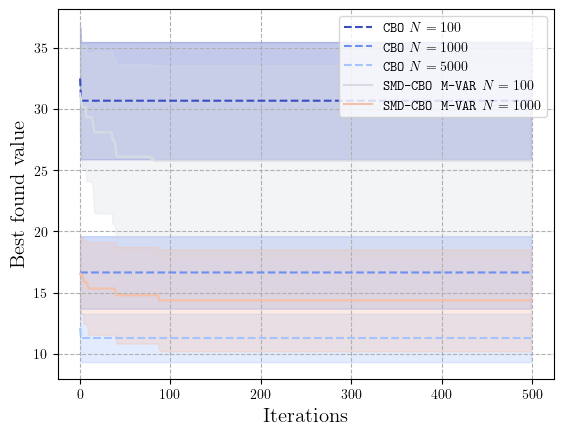

In [ ]:
alg_name = "CBO"
cn_alg_name = "SMD-CBO"

latex_label = lambda s: r"\texttt{" + s.replace("_", r"\_") + "}"

cmap = matplotlib.colormaps["coolwarm"]

c0 = cmap(0)
c1 = cmap(0.16)
c2 = cmap(0.32)
c3 = cmap(0.48)
c4 = cmap(0.64)
c5 = cmap(0.9)
c6 = cmap(1)

fig, ax = plt.subplots()

coeff = 1.5

""" mean = mins_10.mean(axis=0)
std = mins_10.std(axis=0)
ax.plot(mean, label=latex_label(alg_name) + " $N = 10$", linestyle="--", color=c0)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c0) """

mean = mins_100.mean(axis=0)
std = mins_100.std(axis=0)
ax.plot(mean, label=latex_label(alg_name) + " $N = 100$", linestyle="--", color=c0)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c0)

mean = mins_1000.mean(axis=0)
std = mins_1000.std(axis=0)
ax.plot(mean, label=latex_label(alg_name) + " $N = 1000$", linestyle="--", color=c1)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c1)

mean = mins_5000.mean(axis=0)
std = mins_5000.std(axis=0)
ax.plot(mean, label=latex_label(alg_name) + " $N = 5000$", linestyle="--", color=c2)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c2)

mean = mins_mvar_100.mean(axis=0)
std = mins_mvar_100.std(axis=0)
ax.plot(mean, label=latex_label(f"{cn_alg_name} M-VAR") + " $N = 100$", linestyle="-", c=c3)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c3)

mean = mins_mvar_1000.mean(axis=0)
std = mins_mvar_1000.std(axis=0)
ax.plot(mean, label=latex_label(f"{cn_alg_name} M-VAR") + " $N = 1000$", linestyle="-", c=c4)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c4)

""" mean = mins_mvar_5000.mean(axis=0)
std = mins_mvar_5000.std(axis=0)
ax.plot(mean, label=latex_label(f"{cn_alg_name} M-VAR") + " $N = 5000$", linestyle="-", c=c6)
ax.fill_between(range(iter), mean - (std / coeff), mean + (std / coeff), alpha=0.3, color=c6) """

ax.set_xlabel(r"$\textrm{Iterations}$", fontsize=15)
ax.set_ylabel(r"$\textrm{Best found value}$", fontsize=15)
ax.grid(linestyle="--")
ax.legend()

#plt.yscale("log")

in_status = "IN" if independent_noise else "no_IN"

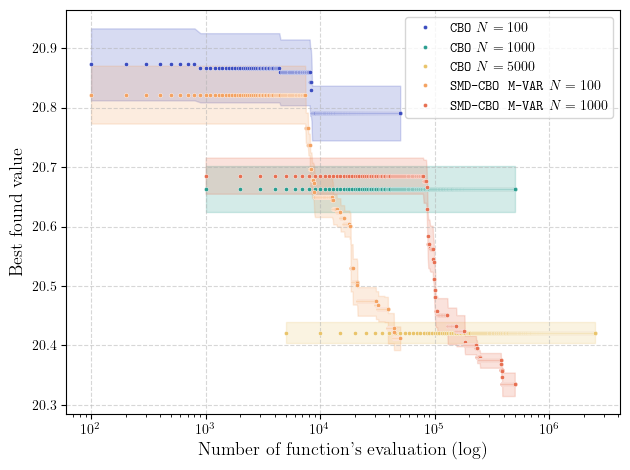

In [ ]:
import numpy as np

alg_name = "CBO"
cn_alg_name = "SMD-CBO"

latex_label = lambda s: r"\texttt{" + s.replace("_", r"\_") + "}"

colors = ["#3b4cc0", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]

fig, ax = plt.subplots()

def plot_series(mins, step, color, label):
    mean = mins.mean(axis=0)
    std = mins.std(axis=0)
    xs = np.array([i * step for i in range(1, iter + 1)])

    ax.plot(xs, mean, 'o', markersize=3, color=color, label=label,
             zorder=3, markeredgecolor='white', markeredgewidth=0.3)
    ax.fill_between(xs, mean - std / 3, mean + std / 3, color=color, alpha=0.2, zorder=1)

#plot_series(mins_10,   10,   colors[0], latex_label(alg_name) + r" $N = 10$")
plot_series(mins_100,  100,  colors[0], latex_label(alg_name) + r" $N = 100$")
plot_series(mins_1000, 1000, colors[1], latex_label(alg_name) + r" $N = 1000$")
plot_series(mins_5000, 5000, colors[2], latex_label(alg_name) + r" $N = 5000$")
plot_series(mins_mvar_100, 100,  colors[3], latex_label(f"{cn_alg_name} M-VAR") + r" $N = 100$")
plot_series(mins_mvar_1000, 1000,  colors[4], latex_label(f"{cn_alg_name} M-VAR") + r" $N = 1000$")
#plot_series(mins_mvar_1000, 5000,  colors[6], latex_label(f"{cn_alg_name} M-VAR") + r" $N = 5000$")

ax.set_xlabel(r"$\textrm{Number of function's evaluation } (\log)$", fontsize=13)
ax.set_ylabel(r"$\textrm{Best found value}$", fontsize=13)
ax.set_xscale("log")

ax.grid(linestyle="--", alpha=0.5)
ax.legend()

fig.tight_layout()
plt.savefig(f"budget_{alg_name.lower()}_{g}.pdf", bbox_inches="tight")